Zadanie: Zaimplementuj krzyżowanie PMX (opisane tu: https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Crossover_for_permutations ). Porównaj czas działania i jakość rozwiązania z krzyżowaniem opartym o inwersje zaimplementowanym poniżej oraz z podejściem opartym o MIP (`tsp_lazy_constraints.ipynb`) na losowych grafach o 20, 40 i 80 wierzchołkach. Zbierz wyniki w tabelkę. Wypróbuj różną liczebność populacji oraz metody wyboru potomstwa.


In [74]:
using Evolutionary
using Random
using Plots

function generate_distance_matrix(n; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    return X, Y, d
end

n = 40
X, Y, d = generate_distance_matrix(n)

([23.603334566204694, 34.651701419196044, 31.27069683360675, 0.790928339056074, 48.86128300795012, 21.096820215853597, 95.1916339835734, 99.99046588986135, 25.166218303197184, 98.66663668987997  …  46.33502459235987, 18.582130997265377, 11.198087695816717, 97.6311881619359, 5.161462067432709, 53.80295812064833, 45.56920516275036, 27.93951106725605, 17.824610354168602, 54.89828719625274], [37.097066286146884, 89.41659192657593, 64.80537482231894, 41.70393538841062, 14.456554241360564, 62.24031828206811, 87.23344353741976, 52.49746566167794, 24.159060827129643, 88.48369255734127  …  66.12321555087209, 19.45678064479248, 39.3193497656424, 99.07406554003964, 55.03342139580574, 58.07816346526631, 76.83586278313636, 51.952465724186084, 51.486297110544356, 99.81360570779374], [0.0 53.473350122820904 … 15.506244459460921 70.09092934998034; 53.473350122820904 0.0 … 41.49527995497558 22.760099542720535; … ; 15.506244459460921 41.49527995497558 … 0.0 60.9096566304971; 70.09092934998034 22.7600995

In [75]:
# Permutation inversion

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

RP = randperm(20)
iRP = perm_to_inv(RP)
println(RP == inv_to_perm(iRP))


true


In [76]:
function has_subtour(perm::Vector)
    c = 1
    for i in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

has_subtour (generic function with 1 method)

In [77]:
function mutate_swap(recombinant::AbstractVector;
    rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end


"""

Implementation follows "Genetic Algorithm Solution of the TSP Avoiding Special Crossover and Mutation"
"""
function recombine_tsp(v1::T, v2::T; rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    crossover_point = rand(2:(N-1))
    i1c = vcat(i1[1:crossover_point], i2[(crossover_point+1):N])
    i2c = vcat(i2[1:crossover_point], i1[(crossover_point+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

recombine_tsp

In [78]:
x0 = [mod1(i+1, n) for i in 1:n]
function cost(x)
    dist = 0.0
    for i in 1:length(x)
        dist += d[i, x[i]]
    end
    if has_subtour(x)
        dist += 5000
    end
    return dist
end
println("Initial cost: $(cost(x0))")

Initial cost: 2187.28032456448


In [116]:

x_sol = Evolutionary.optimize(
    cost,
    x0,
    GA(; populationSize=10000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
println(has_subtour(x_sol.minimizer))
println(x_sol)


false

 * Status: success

 * Candidate solution
    Minimizer:  [38, 40, 6,  ...]
    Minimum:    874.3559178497521
    Iterations: 156

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   8.1904 (vs limit Inf)
    Iterations:    156
    f(x) calls:    1585700



[38, 40, 6, 21, 9, 29, 14, 10, 24, 34, 13, 26, 31, 37, 27, 3, 32, 1, 16, 8, 35, 7, 20, 15, 28, 11, 4, 23, 2, 5, 30, 18, 39, 22, 33, 17, 36, 12, 19, 25]


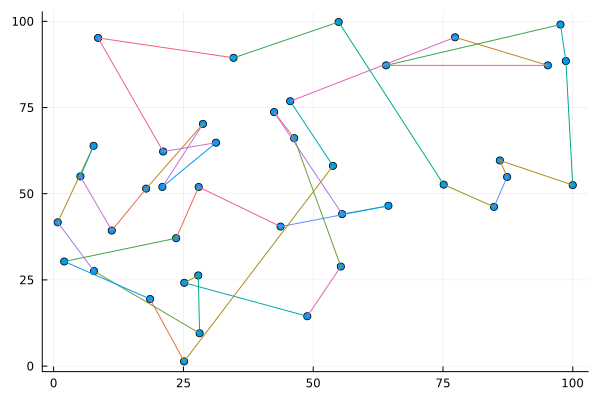

In [117]:
println(x_sol.minimizer)
function plot_tour(X, Y, x)
    plot = Plots.plot()
    scatter!(X, Y)
    for i in 1:length(x)
        j = x[i]
        Plots.plot!(plot, [X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, x_sol.minimizer)